In [ ]:
import torch, pandas as pd, numpy as np, time
import matplotlib.pyplot as plt
import torchvision as tv

## 1. Скачайте тренировочную и тестовою часть датасета Fashion MNIST

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.87MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


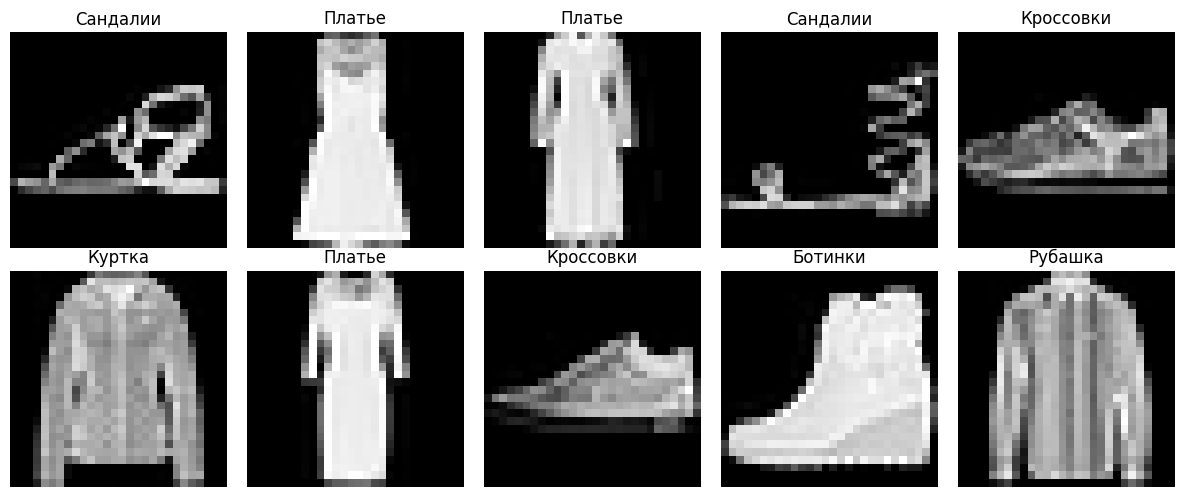

In [ ]:
from torchvision import datasets
import random

# Загрузка FashionMNIST без преобразований
fashion_mnist = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=None  # Без преобразований
)

# Названия классов
class_names = ['Футболка/топ', 'Брюки', 'Свитер', 'Платье', 'Куртка',
               'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

# 10 случайных индексов
random_indices = random.sample(range(len(fashion_mnist)), 10)

# сетка для отображения изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Отображение выбранных изображений
for i, idx in enumerate(random_indices):
    img, label = fashion_mnist[idx]
    # Преобразуем PIL изображение в массив numpy
    img_np = np.array(img)

    # Отображение изображения
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"{class_names[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# загрузка тестового и тренировочных датасетов
train_dataset = tv.datasets.FashionMNIST('.', train=True, transform=tv.transforms.ToTensor(), download=True)
test_dataset = tv.datasets.FashionMNIST('.', train=False, transform=tv.transforms.ToTensor(), download=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.5MB/s]


In [ ]:
# формирование тестового и тренировочных лоадеров с батчами
train_Loader = torch.utils.data.DataLoader(train_dataset, batch_size=256)
test_Loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

In [ ]:
for images, labels in train_Loader:
  print(f"Размер батча: {images.shape}")
  print(f"Размер одного изображения: {images[0].shape}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_Loader)}\n'
      f'Общее количество изображений в датасете: {len(train_Loader.dataset)}\n')

Размер батча: torch.Size([256, 1, 28, 28])
Размер одного изображения: torch.Size([1, 28, 28])
Общее количество батчей: 235
Общее количество изображений в датасете: 60000



## 2. Постройте архитектуру модели, используя свёрточные слои, слои регуляризации и один финальный полносвязный слой

In [ ]:
# Модель LENET
from torch import nn
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=0),
    nn.Tanh(),
    nn.AvgPool2d(2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.Tanh(),
    nn.AvgPool2d(2, stride=2),
    nn.Conv2d(16, 120, kernel_size=5),
    nn.Flatten(),
    nn.Linear(120, 84),
    nn.Tanh(),
    nn.Linear(84, 10)
)

In [ ]:
# МОЯ МОДЕЛЬ
model_1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=12, kernel_size=3, padding=1), # каждый из 12 канал будет иметь размер 28*28
    nn.ELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Уменьшает размер до 14x14
    nn.BatchNorm2d(12),
    nn.Flatten(),
    nn.Linear(12*14*14, 128),  # Исправленный размер входа
    nn.ELU(),
    nn.Linear(128, 10)
)

In [ ]:
from torchsummary import summary
summary(model_1, input_size=(1, 28, 28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 12, 28, 28]             120
               ELU-2           [-1, 12, 28, 28]               0
         MaxPool2d-3           [-1, 12, 14, 14]               0
       BatchNorm2d-4           [-1, 12, 14, 14]              24
           Flatten-5                 [-1, 2352]               0
            Linear-6                  [-1, 128]         301,184
               ELU-7                  [-1, 128]               0
            Linear-8                   [-1, 10]           1,290
Total params: 302,618
Trainable params: 302,618
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.20
Params size (MB): 1.15
Estimated Total Size (MB): 1.36
----------------------------------------------------------------


In [ ]:
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [ ]:
# Фнкция потерь. Она автоматически применяет softmax к выходам модели (не нужно делать это отдельно)
loss = torch.nn.CrossEntropyLoss()

In [ ]:
# ФУНКЦИЯ ОБУЧЕНИЯ МОДЕЛИ
def train_model(model, optimizer_, num_epochs=10): # число эпох по умолчании = 10
    for ep in range(num_epochs):
        train_iters, train_passed  = 0, 0
        train_loss, train_acc = 0., 0.
        start=time.time()

        model.train()
        for X, y in train_Loader:
            optimizer_.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            optimizer_.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)

        test_iters, test_passed  = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        for X, y in test_Loader:
            y_pred = model(X)
            l = loss(y_pred, y)
            test_loss += l.item()
            test_acc += (y_pred.argmax(dim=1) == y).sum().item()
            test_iters += 1
            test_passed += len(X)

        print("ep: {}, taked: {:.3f}, train_loss: {}, train_acc: {}, test_loss: {}, test accuracy: {}".format(
            ep, time.time() - start, train_loss / train_iters, train_acc / train_passed,
            test_loss / test_iters, test_acc / test_passed)
        )

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
trainer_1 = optimizer(model=model_1, lr=0.001)

In [ ]:
train_model(model=model_1, optimizer_=trainer_1)

ep: 0, taked: 23.010, train_loss: 0.42453982392524153, train_acc: 0.8488666666666667, test_loss: 0.3360128831118345, test accuracy: 0.8774
ep: 1, taked: 22.358, train_loss: 0.28750207252958987, train_acc: 0.8952833333333333, test_loss: 0.30533897019922734, test accuracy: 0.8848
ep: 2, taked: 22.434, train_loss: 0.2384407100525308, train_acc: 0.9123833333333333, test_loss: 0.28313904479146, test accuracy: 0.8964
ep: 3, taked: 22.591, train_loss: 0.20179280033136937, train_acc: 0.92665, test_loss: 0.2821673445403576, test accuracy: 0.9026
ep: 4, taked: 22.531, train_loss: 0.17041601155032504, train_acc: 0.9386833333333333, test_loss: 0.27738195434212687, test accuracy: 0.9023
ep: 5, taked: 23.056, train_loss: 0.14457983693226856, train_acc: 0.94815, test_loss: 0.28338697608560326, test accuracy: 0.9052
ep: 6, taked: 23.095, train_loss: 0.122623804290878, train_acc: 0.9570833333333333, test_loss: 0.3059682235121727, test accuracy: 0.9029
ep: 7, taked: 22.065, train_loss: 0.106617454217469